In [1]:
import numpy as np
import pandas as pd
from astropy.table import Table
import astropy.io.ascii as asci
import astropy.constants as const
from astropy.time import Time

from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70., Om0=0.3)

In [2]:
import matplotlib
import matplotlib.pyplot as plt
fs= 10
matplotlib.rcParams['font.size']=fs
ms = 6
matplotlib.rcParams['lines.markersize']=ms

In [3]:
colordict = {'U.uvot': 'darkviolet',
 'B.uvot': 'forestgreen',
 'V.uvot': 'gold',
 'UVW2.uvot': 'k',
 'UVM2.uvot': 'indigo',
 'UVW1.uvot': 'purple',
 'u.sdss': 'darkviolet',
 'g.sdss': 'royalblue',
 'r.sdss': 'crimson',
 'i.sdss': 'goldenrod',
 'z.sdss': 'hotpink',
 'g.ztf': 'royalblue',
 'r.ztf': 'crimson',
 'i.ztf': 'goldenrod',
 'c.atlas': 'MediumAquaMarine',
 'o.atlas': 'darkorange'}

markerdict = {'U.uvot': ['s', 4],
 'B.uvot': ['s', 4],
 'V.uvot': ['s', 4],
 'UVW2.uvot': ['s', 4],
 'UVM2.uvot': ['s', 4],
 'UVW1.uvot': ['s', 4],
 'u.sdss': ['d', 4],
 'g.sdss': ['d', 4],
 'r.sdss': ['d', 4],
 'i.sdss': ['d', 4],
 'z.sdss': ['d', 4],
 'g.ztf': ['o', 4],
 'r.ztf': ['o', 4],
 'i.ztf': ['o', 4],
 'c.atlas': ['o', 4],
 'o.atlas': ['o', 4]}

In [4]:
def plot_uvopt_lc(name):
    if name == "ZTF24aapvieu":
        mjd0 = 60460.24495
        z = 0.192
        ATname = "AT2024kmq"
        mjd_min = 60450
        xmax = 600
    elif name == "ZTF24aaoxmyb":
        mjd0 = 60424.40988
        z = 0.2045
        ATname = "AT2024lhc"
        mjd_min = 60420
        xmax = 550
    atname = ATname.lower()
    SNT = 3
    SNT_uv = 2
    SNT_upp = 3
    
    D = cosmo.luminosity_distance([z])[0].value * 1e+6 # in pc
    D_cm = D * const.pc.cgs.value
    multi = 4 * np.pi * D_cm**2

    filename1 = '../data/%s_grouped_lc.dat'%(name)
    tb = asci.read(filename1)
    ixno1 = tb["filter"]=="B.uvot"
    ixno2 = tb["filter"]=="V.uvot"
    ixno = ixno1 | ixno2
    tb = tb[~ixno]
    tb = tb[tb["mjd"]>mjd_min]
    
    filters = tb["filter"].data
    ix_opt = np.array(["uvot" not in x for x in filters])
    myfilters = np.unique(filters)
    data = tb["uJy.0"].data
    edata = tb["duJy.0"].data
    
    
    ixdet_opt = (data > (SNT * edata))&ix_opt
    ixdet_uv = (data > (SNT_uv * edata))&(~ix_opt)
    ix = ixdet_opt | ixdet_uv
    tb_det = tb[ix]
    tb_nondet = tb[~ix]
    
    fig = plt.figure(figsize = (10.5, 6.5))
    gs = fig.add_gridspec(3, 1, hspace=0., wspace = 0,
                          height_ratios = [1.6, 1.1, 0.8])
    axs = gs.subplots(sharex=True)

    ax = axs[0]
    ax1 = axs[1]
    ax2 = axs[2]
    
    for i in range(len(myfilters)):
        myfilter = myfilters[i]
        color = colordict[myfilter]
        marker = markerdict[myfilter][0]
        #ms = markerdict[myfilter][1]
        ind_det = tb_det["filter"] == myfilter
        ind_nondet = tb_nondet["filter"] == myfilter
        
        text1 = myfilter.split(".")[0]
        text2 = myfilter.split(".")[1]
        if text2 == "uvot":
            text2 = "UVOT"   
            if len(text1) == 4:
                text1 = text1.lower()
        if text2 == "ztf":
            text2 =  "ZTF"
        myfilter_text = r"$%s_{\rm %s}$"%(text1, text2)
        
        tt_det = tb_det[ind_det]["mjd"]
        ett_det = tb_det[ind_det]["mjd_err"]
        flux = tb_det[ind_det]["uJy.0"]
        eflux = tb_det[ind_det]["duJy.0"]
        mag = -2.5 * np.log10(flux*1e-6 / 3631)
        emag = 2.5 / np.log(10) * eflux / flux
        if "uvot" in myfilter:
            zorder = 10
            markerfacecolor = "none"
        else:
            zorder = 5
            markerfacecolor = color
        if "ztf" in myfilter:
            markeredgecolor = "k"
        else:
            markeredgecolor = color
        xx = (tt_det-mjd0)#/(1+z)
        ax.errorbar(xx, mag, emag, xerr=ett_det,
                    fmt = marker, color = color, label = myfilter_text,
                    markersize = ms/2, zorder=zorder, markeredgecolor=markeredgecolor,
                    markerfacecolor=markerfacecolor)
        
        tt_nondet = tb_nondet[ind_nondet]["mjd"]
        ett_nondet = tb_nondet[ind_nondet]["mjd_err"]
        flux_nondet = tb_nondet[ind_nondet]["uJy.0"]
        eflux_nondet = tb_nondet[ind_nondet]["duJy.0"]
        limflux = SNT_upp * eflux_nondet
        limmag = -2.5 * np.log10(limflux*1e-6 / 3631)
        deepix1 = (limmag > 19.5)&(tt_nondet < (50+mjd0))
        deepix2 = (limmag > 20.2)&(tt_nondet > (50+mjd0))
        deepix = deepix1 | deepix2
        xxn = (tt_nondet[deepix]-mjd0)#/(1+z)
        ax.errorbar(xxn, limmag[deepix], 
                    xerr = ett_nondet[deepix], 
                    fmt ="v", color = color, 
                    markersize = ms/2, linestyle = "none", alpha = 0.2, zorder=zorder,
                    markerfacecolor = markerfacecolor)
    
    ax2.set_xlabel(r"$t_{\rm obs}$"+" (d)", fontsize = fs+1)
    ax.set_ylabel("AB mag", fontsize = fs+1)
    ymin, ymax = ax.get_ylim()
    if atname == "at2024lhc":
        ymin -= 0.4
    else:
        ymin += 0
        ymax += 0
    ax.set_ylim(ymax, ymin)
    
    # add epochs of optical spectroscopy
    if atname == "at2024lhc":
        mjds = [52791.42396331, 59335.43713588, 60475.417,      60489.30399306,
                 60493.50099537, 60520.381,      60537.20899306, 60550.23998843,
                 60739.60199074, 60827.52299769, 60832.        ]
    else:
        mjds = [60469.30256944, 60643.02792824, 60652.22617141, 60851.305 ]
    mjds = np.array(mjds)
    phases = (mjds - mjd0)#/(1+z)
    phases = phases[phases>0]
    for i in range(len(phases)):
        if atname == "at2024kmq" and i==0:
            continue
        xx = phases[i]
        ax.plot([xx, xx], [ymin, ymin+0.2], color = "darkcyan")
        ax.text(xx-2.5, ymin+0.5, "S", color = "darkcyan")
    
    # add HST epoch
    if atname == "at2024lhc":
        mjd = Time("2025-06-06").mjd
        x = mjd - mjd0
        xx = x / (1+z)
        ax.plot([x, x], [ymin, ymax], color = "k", linestyle = ":")
        ax.text(x, ymin+1, "H", color = "k")
            
    if atname == "at2024kmq":
        ax.legend(ncol = 7, loc = "lower left", handletextpad=0.2, labelspacing=0.2, 
                  columnspacing=0.3, borderpad=0.2, handlelength=0.6, bbox_to_anchor=(0.03,0))
    else:
        ax.legend(ncol = 7, loc = "lower left", handletextpad=0.2, labelspacing=0.2, 
                  columnspacing=0.5, borderpad=0.2, handlelength=0.8)
        
    # Plot XRT light curve
    lc = asci.read("../data/%s_xrtlc_1_withflux2.dat"%ATname)
    ixupp = lc["flux_err"].data==0
    ax1.errorbar(lc["mjd"][~ixupp]-mjd0, lc["flux"][~ixupp], 
                 lc["flux_err"][~ixupp], xerr = lc["mjd_err"].data[~ixupp],
                 fmt = ".k", capsize = 2, zorder = 2, label = "XRT")
    ax1.plot(lc["mjd"][ixupp]-mjd0, lc["flux"][ixupp], "v", color = "k", alpha =0.5)
    ax1.semilogy()
    
    ax1.set_ylabel(r"$f_{\rm X}\;(\rm erg\,s^{-1}\,cm^{-2})$", fontsize = fs+1)
    
    # Plot XRT best-fit parameters
    df = asci.read("../data/%s_xrtsp_stacked_pars.dat"%ATname)
    df["mjd_err"] = (df["mjd_end"] - df["mjd_start"])/2
    ax2.errorbar(df["mjd"].data-mjd0, df["Gamma"].data, 
                 yerr=[df["Gamma_left"].data, df["Gamma_right"].data], 
                 xerr = df["mjd_err"].data,  fmt = ".k", capsize = 2, zorder = 2)
    
    # Plot NICER light curve
    tbn = pd.read_csv("../data/%s_nicer_detections.csv"%atname)
    tbn = Table.from_pandas(tbn)
    
    ax1.errorbar(tbn["t_mjd"]-mjd0, tbn["flux"], 
                 yerr = [-tbn['flux_lo'], tbn['flux_hi']],
                 fmt = ".", color = "goldenrod", zorder = 1, label = "NICER", linewidth = 1)
    
    ax2.errorbar(tbn["t_mjd"]-mjd0, tbn["phoindex"], 
                 yerr = [-tbn['phoindex_lo'], tbn['phoindex_hi']],
                 fmt = ".", color = "goldenrod", zorder = 1, linewidth = 1)
    
    show_ni_upp = False
    if show_ni_upp :
        tbn_upp = pd.read_csv("../data/%s_nicer_upperlims.csv"%atname)
        ax1.plot(tbn_upp["t_mjd"]-mjd0, tbn_upp["flux"], linestyle= "none",
                 alpha = 0.5, marker = "v", color = "goldenrod", zorder = 1,
                 markeredgewidth = 0, markersize = 4)
        
    
    ax2.set_ylabel(r"$\Gamma$", fontsize = fs+1)
    
    ymin1, ymax1 = ax1.get_ylim()
    ymax1 *= 1.5
    ymin2, ymax2 = ax2.get_ylim()
    
    # add VLA epoch
    if atname == "at2024kmq":
        mjds = np.array([#60475.98,
                         #60505.82,
                         #60536.08,
                         #60565.03 ,
                         Time("2025-01-17").mjd+0.6,
                         Time("2025-02-27").mjd+0.4,
                         Time("2025-07-15").mjd+0.2])
    
    if atname == "at2024lhc":
        mjds = np.array([Time("2024-07-10").mjd,
                         Time("2024-08-25").mjd+0.8,
                         Time("2024-10-22").mjd+0.7,
                         Time("2025-01-17").mjd+0.4,
                         Time("2025-05-26").mjd+0.2])
    phases = (mjds - mjd0)#/(1+z)
    phases = phases[phases>0]
    for i in range(len(phases)):
        xx = phases[i]
        ax1.plot([xx, xx], [ymax1, ymax1*0.82], color = "darkcyan")
        ax1.text(xx-2.5, ymax1*0.57, "R", color = "darkcyan")
    
    # Add XMM-Newton epoch
    if atname == "at2024lhc":
        mjds_xmm1 = np.array([Time('2024-09-23T08:31:32').mjd,
                              Time('2024-09-23T12:37:33').mjd])
        mjd_xmm1 = (mjds_xmm1[0]+mjds_xmm1[1])/2.
        emjd_xmm1 = (mjds_xmm1[1]-mjds_xmm1[0])/2.
        
        mjds_xmm2 = np.array([Time('2025-08-14T13:40:29').mjd,
                              Time('2025-08-14T18:03:12').mjd])
        mjd_xmm2 = (mjds_xmm2[0]+mjds_xmm2[1])/2.
        emjd_xmm2 = (mjds_xmm2[1]-mjds_xmm2[0])/2.
        ax1.errorbar([mjd_xmm1-mjd0, mjd_xmm2-mjd0], 
                     [4.39e-13, 0.67e-13], 
                     xerr = [emjd_xmm1, emjd_xmm2], 
                     yerr=[[0.23e-13, 0.12e-13], [0.22e-13, 0.26e-13]], 
                     zorder=20, markersize = ms, capsize = 2,
                     fmt = "s", markerfacecolor = "none", 
                     color = "steelblue", label = "XMM-Newton")
        ax2.errorbar([mjd_xmm1-mjd0, mjd_xmm2-mjd0], 
                     [2.13, 2.06], 
                     xerr = [emjd_xmm1,  emjd_xmm2], yerr=[0.06, 0.225], 
                     zorder=20, markersize = ms, capsize = 2,
                     fmt = "s", markerfacecolor = "none", 
                     color = "steelblue", label = "XMM-Newton")
        
    # Add NuSTAR epochs
    if atname == "at2024kmq":
        e1_start = 60616.1432
        e1_end = 60617.5529
        mjd_nu1 = (e1_start+e1_end)/2.
        emjd_nu1 = (-e1_start+e1_end)/2.
        e2_start = 60704.5320
        e2_end = 60704.9904
        mjd_nu2 = (e2_start+e2_end)/2.
        emjd_nu2 = (-e2_start+e2_end)/2.
        e3_start = 60716.9036
        e3_end = 60717.3515
        mjd_nu3 = (e3_start+e3_end)/2.
        emjd_nu3 = (-e3_start+e3_end)/2.
        e4_start = 60738.5807
        e4_end = 60739.6258
        mjd_nu4 = (e4_start+e4_end)/2.
        emjd_nu4 = (-e4_start+e4_end)/2.
        xs = np.array([mjd_nu1-mjd0, mjd_nu2-mjd0, mjd_nu3-mjd0, mjd_nu4-mjd0])
        exs = np.array([emjd_nu1, emjd_nu2, emjd_nu3, emjd_nu4])
        Gammas = np.array([2.59, 1.63, 1.72, 1.59])
        eGammas_left = np.array([0.18, 0.22, 0.17, 0.18])
        eGammas_right = np.array([0.17, 0.20, 0.16, 0.16])
        fls = np.array([3.68e-13, 3.66e-13, 2.75e-13, 1.91e-13])
        efls_left = np.array([0.66e-13, 0.64e-13, 0.51e-13, 0.46e-13])
        efls_right = np.array([0.87e-13, 0.61e-13, 0.39e-13, 0.20e-13])
    elif atname == "at2024lhc":
        mjds_nu1 = np.array([Time("2024-07-03T01:56:13").mjd,
                         Time("2024-07-04T05:39:58").mjd])
        mjd_nu1 = (mjds_nu1[0]+mjds_nu1[1])/2.
        emjd_nu1 = (mjds_nu1[1]-mjds_nu1[0])/2.
        xs = np.array([mjd_nu1-mjd0])
        exs = np.array([emjd_nu1])
        fls = np.array([6.46e-13])
        efls_left = np.array([0.39e-13])
        efls_right = np.array([0.42e-13])
        Gammas = np.array([1.93])
        eGammas_left = np.array([0.05])
        eGammas_right = np.array([0.05])
    ax1.errorbar(xs, fls, xerr = exs, 
                 yerr=[efls_left, efls_right], zorder=20,
                 fmt = "D", markerfacecolor = "none", color = "crimson", label = "NuSTAR+XRT")
    ax2.errorbar(xs, Gammas, xerr = exs, 
                 yerr=[eGammas_left, eGammas_right], zorder=20,
                 fmt = "D", markerfacecolor = "none", color = "crimson", label = "NuSTAR+XRT")
        
    # ADD CXO epochs
    if atname == "at2024kmq":
        e1_start = 60800.28387731 
        e1_end = 60800.4769213
        fl = 9.938e-14
        efl_l = 1.328e-14
        efl_r = 1.132e-14
        Gamma = 1.77
        eGamma_l = 0.27
        eGamma_r = 0.27
    elif atname == "at2024lhc":
        e1_start = 60801.60130787 
        e1_end = 60801.78548611
        fl = 3.05e-13
        efl_l = 1.7e-14
        efl_r = 2.0e-14
        Gamma = 1.74
        eGamma_l = 0.17
        eGamma_r = 0.17
    mjd_cxo1 = (e1_start+e1_end)/2.
    emjd_cxo1 = (-e1_start+e1_end)/2.
    xs = np.array([mjd_cxo1-mjd0])
    exs = np.array([emjd_cxo1])
    ax1.errorbar(xs, [fl], xerr = exs, yerr=[[efl_l], [efl_r]], zorder=20,
                 fmt = "P", markerfacecolor = "none", color = "forestgreen", label = "Chandra")
    ax2.errorbar(xs, [Gamma], xerr = exs, yerr=[[eGamma_l], [eGamma_r]], zorder=20,
                 fmt = "P", markerfacecolor = "none", color = "forestgreen", label = "Chandra")
    
    for i in range(3):
        myright = False
        if i==2:
            myright = True
        mytop = True
        if i==0:
            mytop = False
        axs[i].tick_params(which = 'major', length = 4, top=mytop, direction = "in", right = myright)
        axs[i].tick_params(which = 'minor', length = 2, top=mytop, direction = "in", right = myright)
    
    xmajor = 100
    xminor = 10
    ax.xaxis.set_major_locator(plt.MultipleLocator(xmajor))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(xminor))
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.2))
    
    add_twin_yticks(ax, z)
    
    xmin, xx = ax2.get_xlim()
    xmin = -10
    ax2.set_xlim(xmin, xmax)
    ax2.set_ylim(ymin2, ymax2)
    ax2.grid(linestyle=":")
    
    ax.annotate("AT"+atname[2:], (0.88, 0.82), xycoords="axes fraction", weight = "bold",
                fontsize = fs+1)
    
    ########## upper x axis ##########
    axi1 = ax.twiny()
    axi1.tick_params(which = 'major', length = 4, direction = "in")
    axi1.tick_params(which = 'minor', length = 2, direction = "in")
    
    
    xlims1 = (xmin/(1+z), xmax/(1+z))
    xticks1_label = create_new_xticks1(xlims1, which = "major")
    xticks1_real = []
    for x in xticks1_label:
        xticks1_real.append(x*(1+z))
    xticks1_real = np.array(xticks1_real)
    
    xticks1_label_minor = create_new_xticks1(xlims1, which = "minor")
    xticks1_real_minor = []
    for x in xticks1_label_minor:
        xticks1_real_minor.append(x*(1+z))
    xticks1_real_minor = np.array(xticks1_real_minor)
    
    axi1.set_xticks(xticks1_real, minor = False)
    axi1.set_xticks(xticks1_real_minor, minor = True)
    axi1.set_xlim(xmin, xmax)
    axi1.set_xticklabels(xticks1_label)
    axi1.set_xlabel(r"$t_{\rm rest}$"+" (d)")
    
    
    ########## right y axis ##########
    ########## from fx to Lx
    ax1.set_ylim(ymin1, ymax1)
    ax1.annotate("0.3--10 keV", (0.88, 0.82), xycoords="axes fraction")
    axL = ax1.twinx()
    axL.tick_params(which = 'major', length = 4, direction = "in")
    axL.tick_params(which = 'minor', length = 2, direction = "in")
    ymin1_ = ymin1 * multi
    ymax1_ = ymax1 * multi
    ylims1_ = (ymin1_, ymax1_)
    yticks2_label = create_new_yticks_lum(ylims1_, which = "major")
    yticks2_real = []
    for x in yticks2_label:
        yticks2_real.append(x/multi)
    yticks2_real = np.array(yticks2_real)
    # format yticks2_label
    yticks2_label = [r"$10^{%d}$"%np.log10(x) for x in yticks2_label]
    
    yticks2_label_minor = create_new_yticks_lum(ylims1_, which = "minor")
    yticks2_real_minor = []
    for x in yticks2_label_minor:
        yticks2_real_minor.append(x/multi)
    yticks2_real_minor = np.array(yticks2_real_minor)
   
    axL.semilogy()
    axL.set_yticks(yticks2_real, minor = False)
    axL.set_yticklabels(yticks2_label, minor = False)
    axL.set_yticks(yticks2_real_minor, minor = True)
    axL.set_yticklabels([], minor = True)
    axL.set_ylim(ymin1, ymax1)
    axL.set_ylabel(r"$L_{\rm X}\;(\rm {erg\,s^{-1}})$", fontsize = fs+1)
    
    if atname == "at2024lhc":
        ax1.legend(loc = "lower left", handletextpad=0.5, labelspacing=0.2, 
                   columnspacing=0.5, borderpad=0.5, handlelength=0.8, ncol=3)
    elif atname == "at2024kmq":
        ax1.legend(loc = "lower left", handletextpad=0.5, labelspacing=0.2, 
                   columnspacing=0.5, borderpad=0.5, handlelength=0.8, ncol=4)
    
    if atname == "at2024lhc":
        ax2.set_ylim(1.2-0.5, 3.6-0.5)
    else:
        ax2.set_ylim(1.2, 3.6)
    ax2.yaxis.set_major_locator(plt.MultipleLocator(1))
    ax2.yaxis.set_minor_locator(plt.MultipleLocator(0.2))
    plt.tight_layout(rect = (-0.01, -0.02, 1.01, 1.01))
    figname = "../figs/%s_lc.pdf"%atname
    print ("Saving to %s"%figname)
    plt.savefig(figname)
    
    plt.show()

In [5]:
def create_new_yticks2(ylims2, which = "major"):
    yticks2_new = []
    if which == "major":
        candi = np.arange(-27, -10, 1)
    else:
        candi = np.arange(-27, -10, 0.2)
    for x in candi:
        if x<ylims2[0] and x>ylims2[1]:
            yticks2_new.append(x)
    yticks2_new = np.array(yticks2_new)
    return yticks2_new


def create_new_xticks1(xlims1, which = "major"):
    xticks1_new = []
    if which=="major":
        candi = np.arange(-100, 3000, 100)
    else:
        candi = np.arange(-100, 3000, 10)
    for x in candi:
        if x>xlims1[0] and x<xlims1[1]:
            xticks1_new.append(x)
    xticks1_new = np.array(xticks1_new)
    return xticks1_new


def create_new_yticks_lum(ylims2, which = "major"):
    yticks2_new = []
    if which=="major":
        candi = np.array([1e+40, 1e+41, 1e+42, 1e+43, 1e+44])
    else:
        candi = np.hstack([np.arange(10)[1:]*1e+40,
                           np.arange(10)[1:]*1e+41,
                           np.arange(10)[1:]*1e+42,
                           np.arange(10)[1:]*1e+43,
                           np.arange(10)[1:]*1e+44])
    for x in candi:
        if x>ylims2[0] and x<ylims2[1]:
            yticks2_new.append(x)
    yticks2_new = np.array(yticks2_new)
    return yticks2_new
    

def add_twin_yticks(ax, z):
    D = cosmo.luminosity_distance([z])[0].value * 1e+6 # in pc
    dis_mod = 5*np.log10(D/10) - 2.5 * np.log10(1+z)
    
    ylims1 = ax.get_ylim()
    ylims1 = list(ylims1)
    if ylims1[0] > 25:
        ylims1[0] = 25
    if ylims1[1] < 10:
        ylims1[1] = 10
    ylims1 = tuple(ylims1)
    ylims2 = (ylims1[0] - dis_mod, ylims1[1] - dis_mod)
    
    yticks2_label = create_new_yticks2(ylims2, which = "major")
    yticks2_real = []
    for x in yticks2_label:
        yticks2_real.append(x + dis_mod)
    yticks2_real = np.array(yticks2_real)
    
    yticks2_label_minor = create_new_yticks2(ylims2, which = "minor")
    yticks2_real_minor = []
    for x in yticks2_label_minor:
        yticks2_real_minor.append(x + dis_mod)
    yticks2_real_minor = np.array(yticks2_real_minor)
    
    axi2 = ax.twinx()
    axi2.set_yticks(yticks2_real, minor = False)
    axi2.set_yticks(yticks2_real_minor, minor = True)
    axi2.set_ylim(ylims1[0], ylims1[1])
    axi2.set_yticklabels(yticks2_label)
    axi2.set_ylabel("Absolute mag", fontsize = fs+1)
    
    ax.set_ylim(ylims1[0], ylims1[1])

In [6]:
def show_precursor(name, ax):
    
    if name == "ZTF24aapvieu":
        mjd0 = 60460.24495
        z = 0.192
        ATname = "AT2024kmq"
        mjd_min = 60450
    elif name == "ZTF24aaoxmyb":
        mjd0 = 60424.40988
        z = 0.2045
        ATname = "AT2024lhc"
        mjd_min = 60420
    atname = ATname.lower()
    SNT = 3
    SNT_uv = 2
    SNT_upp = 3

    filename1 = '../data/%s_grouped_lc.dat'%(name)
    tb = asci.read(filename1)
    tb["x"] = (tb["mjd"]-mjd0)/(1+z)
    tb = tb[tb["x"]>-2]
    tb = tb[tb["x"]<30]
    ixno1 = tb["filter"]=="B.uvot"
    ixno2 = tb["filter"]=="V.uvot"
    ixno = ixno1 | ixno2
    tb = tb[~ixno]
    tb = tb[tb["mjd"]>mjd_min]
    
    filters = tb["filter"].data
    ix_opt = np.array(["uvot" not in x for x in filters])
    myfilters = np.unique(filters)
    data = tb["uJy.0"].data
    edata = tb["duJy.0"].data
    
    
    ixdet_opt = (data > (SNT * edata))&ix_opt
    ixdet_uv = (data > (SNT_uv * edata))&(~ix_opt)
    ix = ixdet_opt | ixdet_uv
    tb_det = tb[ix]
    tb_nondet = tb[~ix]
    
    
    for i in range(len(myfilters)):
        myfilter = myfilters[i]
        color = colordict[myfilter]
        marker = markerdict[myfilter][0]
        #ms = markerdict[myfilter][1]
        ind_det = tb_det["filter"] == myfilter
        ind_nondet = tb_nondet["filter"] == myfilter
        
        text1 = myfilter.split(".")[0]
        text2 = myfilter.split(".")[1]
        #print (text1, text2)
        if text2 == "uvot":
            text2 = "UVOT"   
            if len(text1) == 4:
                text1 = text1.lower()
        if text2 == "ztf":
            text2 =  "ZTF"
        myfilter_text = r"$%s_{\rm %s}$"%(text1, text2)
        
        tt_det = tb_det[ind_det]["mjd"]
        ett_det = tb_det[ind_det]["mjd_err"]
        flux = tb_det[ind_det]["uJy.0"]
        eflux = tb_det[ind_det]["duJy.0"]
        if "uvot" in myfilter:
            zorder = 10
            markerfacecolor = "none"
        else:
            zorder = 5
            markerfacecolor = color
        if "ztf" in myfilter:
            markeredgecolor = "k"
        else:
            markeredgecolor = color
        xx = (tt_det-mjd0)/(1+z)
        ax.errorbar(xx, flux, eflux, xerr=ett_det,
                    fmt = marker, color = color, label = myfilter_text,
                    markersize = ms/2, zorder=zorder, markeredgecolor=markeredgecolor,
                    markerfacecolor=markerfacecolor)
        
        tt_nondet = tb_nondet[ind_nondet]["mjd"]
        ett_nondet = tb_nondet[ind_nondet]["mjd_err"]
        flux_nondet = tb_nondet[ind_nondet]["uJy.0"]
        eflux_nondet = tb_nondet[ind_nondet]["duJy.0"]
        limflux = SNT_upp * eflux_nondet
        limmag = -2.5 * np.log10(limflux*1e-6 / 3631)
        deepix1 = (limmag > 19.5)&(tt_nondet < (50+mjd0))
        deepix2 = (limmag > 20.2)&(tt_nondet > (50+mjd0))
        deepix = deepix1 | deepix2
        xxn = (tt_nondet[deepix]-mjd0)/(1+z)
        ax.errorbar(xxn, flux_nondet[deepix], 
                    xerr = ett_nondet[deepix], 
                    yerr = eflux_nondet[deepix],
                    fmt = marker, color = color, #label = myfilter_text,
                    markersize = ms/2, zorder=zorder, alpha = 0.2, 
                    markeredgecolor=markeredgecolor,
                    markerfacecolor=markerfacecolor)
    ax.plot([-1, 28], [0,0], color = "silver", linestyle = "--")
    ax.set_xlim(-1, 28)
    if atname == "at2024lhc":
        ymax = 45
    elif atname == "at2024kmq":
        ymax = 65
    ax.set_ylim(-15, ymax)
    
    
    xmajor = 5
    xminor = 1
    ax.xaxis.set_major_locator(plt.MultipleLocator(xmajor))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(xminor))
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
    myright = True
    mytop = True
    ax.tick_params(which = 'major', length = 4, top=mytop, direction = "in", right = myright)
    ax.tick_params(which = 'minor', length = 2, top=mytop, direction = "in", right = myright)
    ax.set_ylabel(r"$f_\nu\;({\rm \mu Jy})$")
    ax.annotate("AT"+atname[2:], (0.4, 0.85), xycoords="axes fraction", weight = "bold")
    ax.legend(loc = "lower right", ncol = 2,
              handletextpad=0.2, labelspacing=0.2, 
              columnspacing=0.3, borderpad=0.2, handlelength=0.6)

In [7]:
def plot_precursor():
    fig = plt.figure(figsize = (5., 4))
    gs = fig.add_gridspec(2, 1, hspace=0.04, wspace = 0.1,
                          height_ratios = [1, 1])
    axs = gs.subplots()
    ax1 = axs[0]
    ax2 = axs[1]
    show_precursor(name="ZTF24aapvieu", ax=ax1)
    show_precursor(name="ZTF24aaoxmyb", ax=ax2)
    ax1.set_xticklabels([])
    ax2.set_xlabel(r"$t_{\rm rest}$"+" (d)")
    plt.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.1, hspace=0.3, wspace=0.3)
    figname = "../figs/precursor.pdf"
    print ("Saving to %s"%figname)
    plt.savefig(figname)
    plt.show()

Saving to ../figs/at2024kmq_lc.pdf


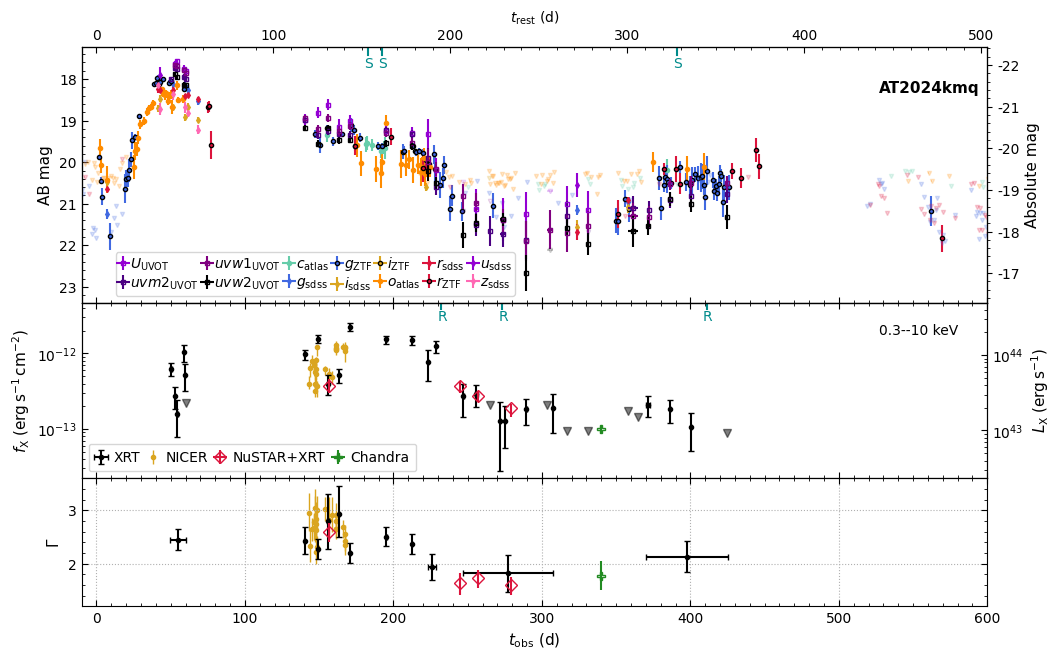

In [8]:
plot_uvopt_lc(name = "ZTF24aapvieu")

Saving to ../figs/at2024lhc_lc.pdf


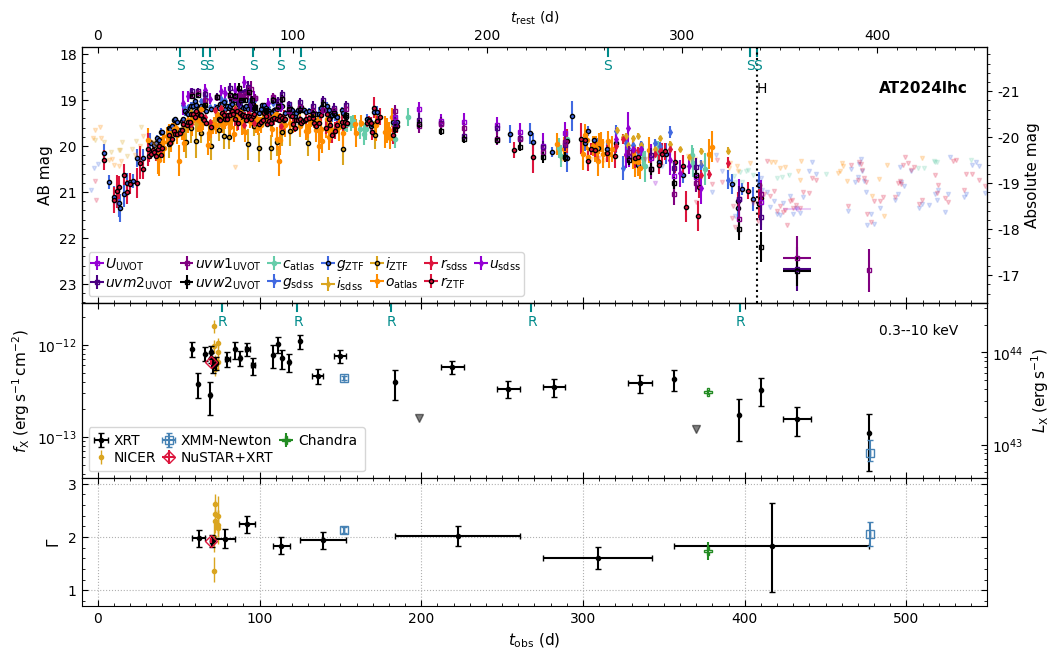

In [9]:
plot_uvopt_lc(name = "ZTF24aaoxmyb")

Saving to ../figs/precursor.pdf


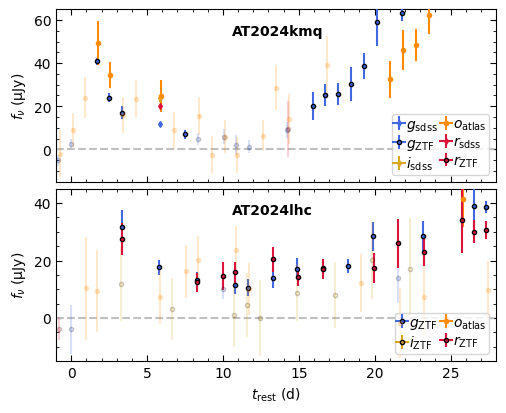

In [10]:
plot_precursor()